In [ ]:
pip install pandas openpyxl

excel -> csv 변환

In [ ]:
import pandas as pd

input_file = '/content/Africa_aggregated_data_up_to_week_of-2026-03-14.xlsx'
output_file = 'Africa_aggregated_data_up_to_week_of-2026-03-14.csv'

df = pd.read_excel(input_file)

df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"변환 완료: {output_file}")

변환 완료: Africa_aggregated_data_up_to_week_of-2026-03-14.csv


In [ ]:
import pandas as pd

input_file = '//content/Asia-Pacific_aggregated_data_up_to_week_of-2026-03-14.xlsx'
output_file = 'Asia-Pacific_aggregated_data_up_to_week_of-2026-03-14.csv'

df = pd.read_excel(input_file)

df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"변환 완료: {output_file}")

변환 완료: Asia-Pacific_aggregated_data_up_to_week_of-2026-03-14.csv


In [ ]:
import pandas as pd

input_file = '/content/Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-14.xlsx'
output_file = 'Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-14.csv'

df = pd.read_excel(input_file)

df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"변환 완료: {output_file}")

변환 완료: Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-14.csv


In [7]:
import pandas as pd

input_file = '/content/US-and-Canada_aggregated_data_up_to_week_of-2026-03-14.xlsx'
output_file = 'US-and-Canada_aggregated_data_up_to_week_of-2026-03-14.csv'

df = pd.read_excel(input_file)

df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"변환 완료: {output_file}")

변환 완료: US-and-Canada_aggregated_data_up_to_week_of-2026-03-14.csv


In [9]:
import pandas as pd

# 1. 병합할 파일 목록
files = [
    '/content/Africa_aggregated_data_up_to_week_of-2026-03-14.csv',
    '/content/Asia-Pacific_aggregated_data_up_to_week_of-2026-03-14.csv',
    '/content/Latin-America-the-Caribbean_aggregated_data_up_to_week_of-2026-03-14.csv',
    '/content/US-and-Canada_aggregated_data_up_to_week_of-2026-03-14.csv', # .xlsx에서 .csv로 변경
    '/content/Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-14.csv',
    '/content/Middle-East_aggregated_data_population_exposure_cleaned.csv'
]

# 2. 모든 파일을 읽어서 리스트에 저장
df_list = []
for f in files:
    temp_df = pd.read_csv(f)
    df_list.append(temp_df)
    print(f"로드 완료: {f} ({temp_df.shape})")

# 3. 데이터프레임 세로 병합 (전체 행 합치기)
merged_all = pd.concat(df_list, axis=0, ignore_index=True)

# 4. 결과 저장 (한글 깨짐 방지를 위해 utf-8-sig 권장)
merged_all.to_csv('merged_all_regions_data.csv', index=False, encoding='utf-8-sig')

print(f"병합 완료! 총 {len(merged_all):,}행의 데이터가 생성되었습니다.")

로드 완료: /content/Africa_aggregated_data_up_to_week_of-2026-03-14.csv ((267956, 13))
로드 완료: /content/Asia-Pacific_aggregated_data_up_to_week_of-2026-03-14.csv ((207468, 13))
로드 완료: /content/Latin-America-the-Caribbean_aggregated_data_up_to_week_of-2026-03-14.csv ((170812, 13))
로드 완료: /content/US-and-Canada_aggregated_data_up_to_week_of-2026-03-14.csv ((22325, 13))
로드 완료: /content/Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-14.csv ((118133, 13))
로드 완료: /content/Middle-East_aggregated_data_population_exposure_cleaned.csv ((115803, 16))
병합 완료! 총 902,497행의 데이터가 생성되었습니다.


데이터 병합

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_me = pd.read_csv('/content/merged_all_regions_data.csv')
df_gpr = pd.read_csv('/content/28_마스터데이터_선형보간.csv')

/tmp/ipykernel_5265/4284224582.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_me = pd.read_csv('/content/merged_all_regions_data.csv')


In [11]:
# Cat 1: 고강도 군사·무기 공격
cat1_list = ['Armed clash', 'Air/drone strike', 'Shelling/artillery/missile attack', 'Grenade', 'Suicide bomb', 'Chemical weapon']
# Cat 2: 비정규 폭력·인프라 사보타주
cat2_list = ['Attack', 'Remote explosive/landmine/IED', 'Looting/property destruction', 'Disrupted weapons use']
# Cat 3: 사회적 소요·민간 불안
cat3_list = ['Arrests', 'Violent demonstration', 'Protest with intervention', 'Mob violence', 'Excessive force against protesters']
# Cat 4: 정치·지정학적 전환
cat4_list = ['Other', 'Government regains territory', 'Non-state actor overtakes territory']

In [12]:
# 날짜 전처리 (가장 중요한 단계: 병합을 위해 '월요일'로 통일)
df_me['WEEK'] = pd.to_datetime(df_me['WEEK'])
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'])

# [핵심] 월요일 기준으로 날짜 정규화
df_me['WEEK_Norm'] = df_me['WEEK'] - pd.to_timedelta(df_me['WEEK'].dt.dayofweek, unit='D')
df_gpr['WEEK_Norm'] = df_gpr['Date'] - pd.to_timedelta(df_gpr['Date'].dt.dayofweek, unit='D')

## 1. CAT별 GPR과의 관계

In [13]:
def classify_task(sub_event):
    if sub_event in cat1_list: return 'CAT1'
    if sub_event in cat2_list: return 'CAT2'
    if sub_event in cat3_list: return 'CAT3' # Changed from 'CATt3' to 'CAT3'
    if sub_event in cat4_list: return 'CAT4'
    return 'Other'

df_me['Task_Category'] = df_me['SUB_EVENT_TYPE'].apply(classify_task)

# 주간 단위 사건 빈도(EVENTS) 및 사망자(FATALITIES) 집계
me_agg = df_me.groupby(['WEEK_Norm', 'Task_Category']).agg({
    'EVENTS': 'sum',
    'FATALITIES': 'sum'
}).unstack(fill_value=0).reset_index()

# 컬럼명 정리 (예: Cat1_EVENTS, Cat1_FATALITIES)
me_agg.columns = [f"{col[1]}_{col[0]}" if col[1] else col[0] for col in me_agg.columns]

# GPR 주간 평균 계산 및 병합
gpr_weekly = df_gpr.groupby('WEEK_Norm')[['GPR', 'GPR_ACT', 'GPR_THREAT']].mean().reset_index()
merged = pd.merge(me_agg, gpr_weekly, on='WEEK_Norm', how='inner')

# 상관계수 산출
event_cols = ['CAT1_EVENTS', 'CAT2_EVENTS', 'CAT3_EVENTS', 'CAT4_EVENTS']
fatal_cols = ['CAT1_FATALITIES', 'CAT2_FATALITIES', 'CAT3_FATALITIES', 'CAT4_FATALITIES']
gpr_cols = ['GPR', 'GPR_ACT', 'GPR_THREAT']

#사건 빈도(EVENTS) vs GPR 3종 상관계수
corr_events = merged[event_cols + gpr_cols].corr()[gpr_cols].loc[event_cols]

#인명 피해(FATALITIES) vs GPR 3종 상관계수
corr_fatalities = merged[fatal_cols + gpr_cols].corr()[gpr_cols].loc[fatal_cols]

print("--- [검증 결과 1] 사건 빈도(EVENTS) vs GPR 상관계수 ---")
print(corr_events)
print("\n--- [검증 결과 2] 인명 피해(FATALITIES) vs GPR 상관계수 ---")
print(corr_fatalities)

# 기초 통계량 (비중 확인용)
print("\n--- [참고] 카테고리별 누적 데이터량 ---")
summary = pd.DataFrame({
    'Total_Events': [merged['CAT1_EVENTS'].sum(), merged['CAT2_EVENTS'].sum(), merged['CAT3_EVENTS'].sum(), merged['CAT4_EVENTS'].sum()],
    'Total_Fatalities': [merged['CAT1_FATALITIES'].sum(), merged['CAT2_FATALITIES'].sum(), merged['CAT3_FATALITIES'].sum(), merged['CAT4_FATALITIES'].sum()]
}, index=['CAT1', 'CAT2', 'CAT3', 'CAT4'])
print(summary)

--- [검증 결과 1] 사건 빈도(EVENTS) vs GPR 상관계수 ---
                  GPR   GPR_ACT  GPR_THREAT
CAT1_EVENTS  0.218972  0.037386    0.411228
CAT2_EVENTS  0.189845 -0.018127    0.419439
CAT3_EVENTS  0.142560 -0.062317    0.379129
CAT4_EVENTS  0.210231  0.016682    0.417148

--- [검증 결과 2] 인명 피해(FATALITIES) vs GPR 상관계수 ---
                      GPR   GPR_ACT  GPR_THREAT
CAT1_FATALITIES  0.122653 -0.014929    0.277504
CAT2_FATALITIES  0.109656 -0.050872    0.295453
CAT3_FATALITIES  0.019865 -0.002688    0.044425
CAT4_FATALITIES  0.028655 -0.030608    0.094194

--- [참고] 카테고리별 누적 데이터량 ---
      Total_Events  Total_Fatalities
CAT1        937221           1741910
CAT2        429772            591925
CAT3        261464             77363
CAT4         53341            108214


### 시각화

1. EVENT Frequency - GPR 상관관계 히트맵

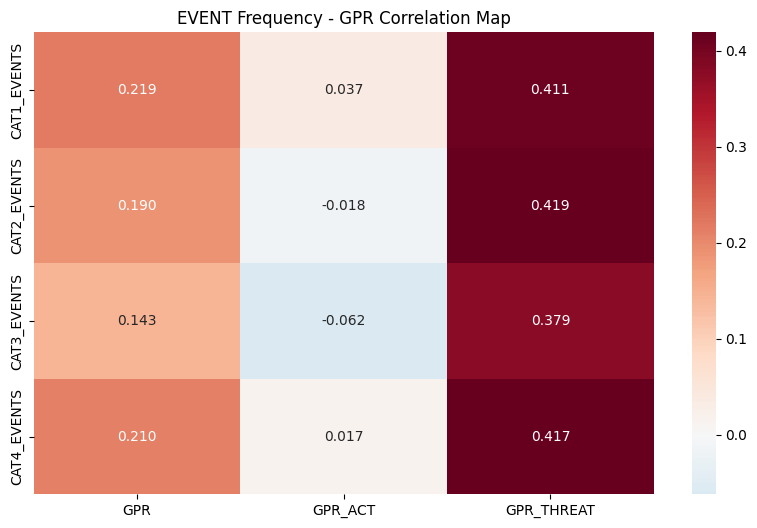

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. EVENT와 GPR 3종 지표 간의 상관계수 산출.
plt.figure(figsize=(10, 6))
sns.heatmap(corr_events, annot=True, cmap='RdBu_r', center=0, fmt=".3f")
plt.title('EVENT Frequency - GPR Correlation Map')
plt.show()

2. FATALITIES - GPR 상관관계 히트맵

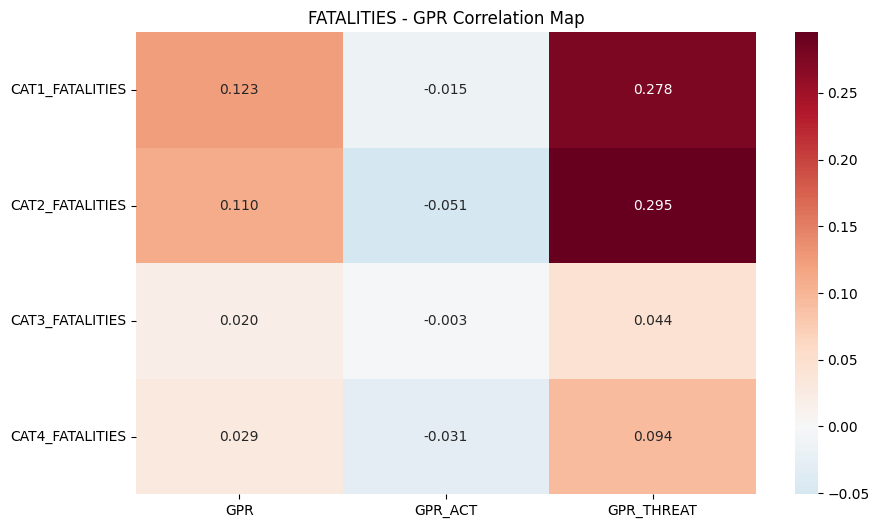

In [16]:
# 2. FATALITIES와 GPR 3종 지표 간의 상관계수 산출
plt.figure(figsize=(10, 6))
sns.heatmap(corr_fatalities, annot=True, cmap='RdBu_r', center=0, fmt=".3f")
plt.title('FATALITIES - GPR Correlation Map')
plt.show()

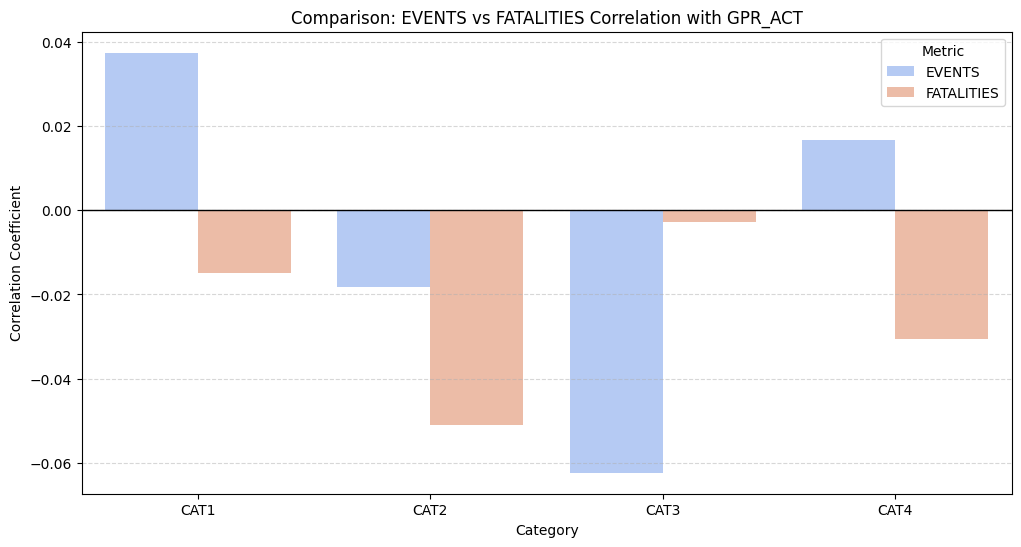

In [18]:
# 시각화를 위한 데이터 재구성 (GPR_ACT 기준 비교)
results = []
for cat in ['CAT1', 'CAT2', 'CAT3', 'CAT4']:
    results.append({'Category': cat, 'Metric': 'EVENTS', 'Corr': corr_events.loc[f'{cat}_EVENTS', 'GPR_ACT']})
    results.append({'Category': cat, 'Metric': 'FATALITIES', 'Corr': corr_fatalities.loc[f'{cat}_FATALITIES', 'GPR_ACT']})

df_plot = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Category', y='Corr', hue='Metric', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.title('Comparison: EVENTS vs FATALITIES Correlation with GPR_ACT')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 2. 설명력 기준: CAT1+CAT2/CAT3+CAT4

In [19]:
# 그룹 생성
merged['Group_A_EVENTS'] = merged['CAT1_EVENTS'] + merged['CAT2_EVENTS']
merged['Group_B_EVENTS'] = merged['CAT3_EVENTS'] + merged['CAT4_EVENTS']

merged['Group_A_FATALITIES'] = merged['CAT1_FATALITIES'] + merged['CAT2_FATALITIES']
merged['Group_B_FATALITIES'] = merged['CAT3_FATALITIES'] + merged['CAT4_FATALITIES']

# 그룹별 상관계수 계산
gpr_cols = ['GPR', 'GPR_ACT', 'GPR_THREAT']

group_cols = ['Group_A_EVENTS', 'Group_B_EVENTS', 'Group_A_FATALITIES', 'Group_B_FATALITIES']

# 그룹별 상관계수 행렬 계산
corr_group = merged[group_cols + gpr_cols].corr()[gpr_cols].loc[group_cols]
print("--- [그룹 분석 결과] 3종 GPR 지수와의 상관계수 ---")
print(corr_group)

--- [그룹 분석 결과] 3종 GPR 지수와의 상관계수 ---
                         GPR   GPR_ACT  GPR_THREAT
Group_A_EVENTS      0.213287  0.021798    0.418748
Group_B_EVENTS      0.157931 -0.048893    0.393673
Group_A_FATALITIES  0.127597 -0.024374    0.299850
Group_B_FATALITIES  0.024990 -0.008527    0.061683


## 시각화

1. EVENT Frequency - GPR 그룹 상관관계 히트맵

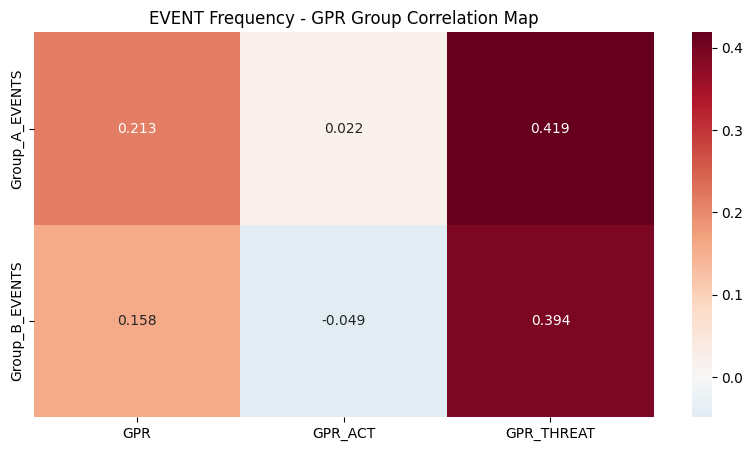

In [33]:
# EVENT 상관관계 행렬 생성
#corr_group 변수에서 EVENT 관련 행만 추출합니다.
# Corrected the row labels to include underscores to match the DataFrame index.
heatmap_events = corr_group.loc[['Group_A_EVENTS', 'Group_B_EVENTS']]

# 시각화
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_events, annot=True, cmap='RdBu_r', center=0, fmt=".3f")
plt.title('EVENT Frequency - GPR Group Correlation Map')
plt.show()

2. FATALITIES - GPR 상관관계 히트맵

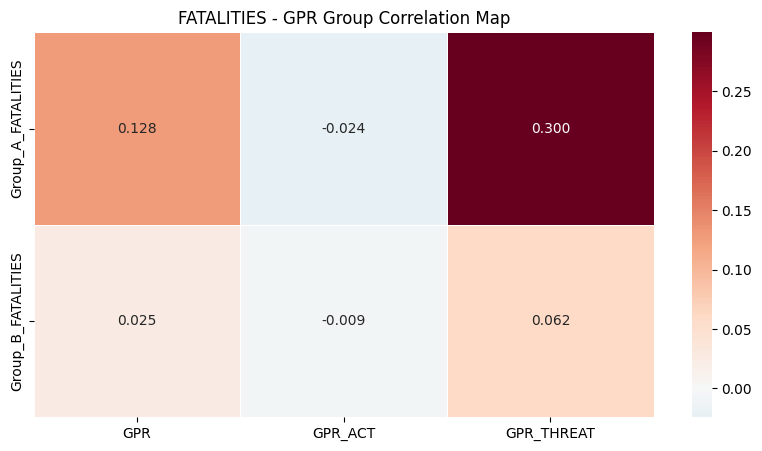

In [21]:
heatmap_fatalities = corr_group.loc[['Group_A_FATALITIES', 'Group_B_FATALITIES']]


plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_fatalities,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt=".3f",
            linewidths=0.5)

plt.title('FATALITIES - GPR Group Correlation Map')
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


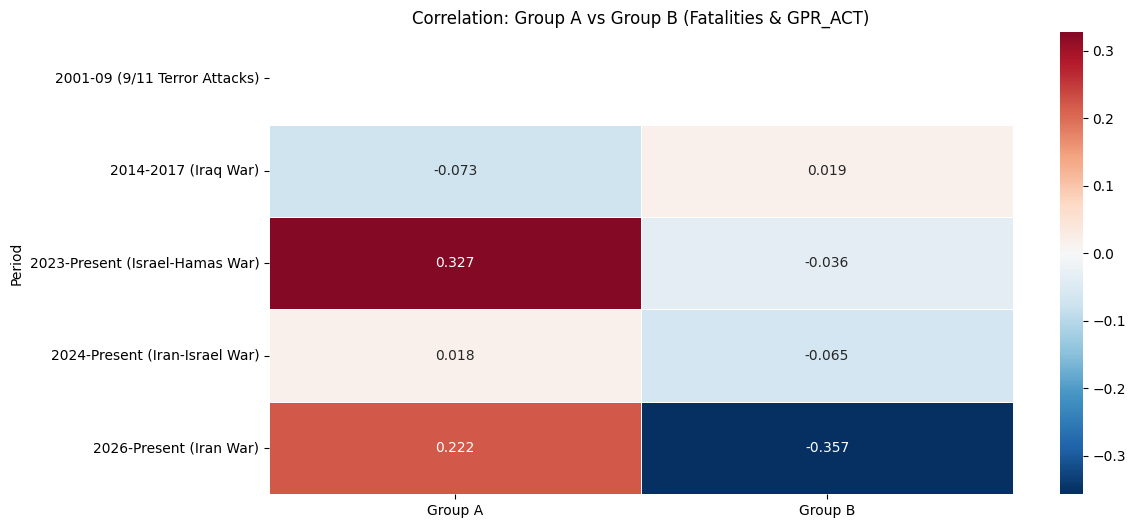

In [35]:
# 전쟁 시기 구분 (날짜 포맷도 Timestamp로 변환)
periods = {
    "2001-09 (9/11 Terror Attacks)": (pd.Timestamp('2001-09-11'), pd.Timestamp('2001-09-22')),
    "2014-2017 (Iraq War)": (pd.Timestamp('2014-12-27'), pd.Timestamp('2017-12-31')),
    "2023-Present (Israel-Hamas War)": (pd.Timestamp('2023-01-01'), pd.Timestamp('2026-03-07')),
    "2024-Present (Iran-Israel War)": (pd.Timestamp('2024-01-01'), pd.Timestamp('2026-03-07')),
    "2026-Present (Iran War)": (pd.Timestamp('2026-01-01'), pd.Timestamp('2026-03-07'))
}

analysis_results = []

for name, (start, end) in periods.items():
    mask = (merged['WEEK_Norm'] >= start) & (merged['WEEK_Norm'] <= end)
    df_p = merged.loc[mask]

    # 데이터가 비어있지 않은지 확인
    if not df_p.empty:
        # 상관계수 계산 (데이터가 너무 적으면 NaN이 나올 수 있음)
        corr_a = df_p['Group_A_FATALITIES'].corr(df_p['GPR_ACT'])
        corr_b = df_p['Group_B_FATALITIES'].corr(df_p['GPR_ACT'])

        analysis_results.append({
            'Period': name,
            'Group A': corr_a,
            'Group B': corr_b
        })

# 결과 데이터프레임 생성
df_comparison = pd.DataFrame(analysis_results).set_index('Period')

# --- 시각화 부분 (계수값이 나오도록 설정) ---
plt.figure(figsize=(12, 6))
sns.heatmap(df_comparison,
            annot=True,      # 상관계수 수치 표시
            cmap='RdBu_r',   # 양수 빨강, 음수 파랑
            center=0,
            fmt=".3f",       # 소수점 3자리
            linewidths=0.5)

plt.title('Correlation: Group A vs Group B (Fatalities & GPR_ACT)')
plt.show()

가설 3

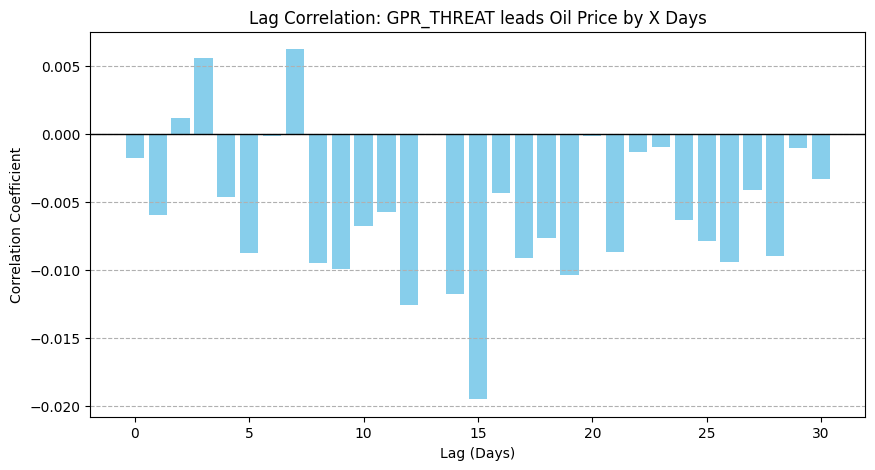

최적의 시차: GPR_THREAT 발생 약 15일 후에 유가 변동성이 가장 큽니다.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Add this line

df_master = pd.read_csv('28_마스터데이터_선형보간.csv')
df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values('Date')

# 2. 유가 변동률(Returns) 계산
# 단순 가격보다 변동률이 GPR과 더 상관관계가 높습니다.
df_master['Oil_Return'] = df_master['Brent'].pct_change()

# 3. 시차 상관관계 (Cross-Correlation) 분석
# GPR_THREAT이 유가에 미치는 영향을 0~8주(60일)까지 밀어보며 확인
lags = range(0, 31) # 0일에서 30일까지의 시차
corrs = [df_master['GPR_THREAT'].corr(df_master['Oil_Return'].shift(-l)) for l in lags]

# 4. 시각화
plt.figure(figsize=(10, 5))
plt.bar(lags, corrs, color='skyblue')
plt.axhline(0, color='black', lw=1)
plt.title('Lag Correlation: GPR_THREAT leads Oil Price by X Days')
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--')
plt.show()

# 가장 상관관계가 높은 시차 확인
best_lag = lags[np.argmax(np.abs(corrs))]
print(f"최적의 시차: GPR_THREAT 발생 약 {best_lag}일 후에 유가 변동성이 가장 큽니다.")

p값 계산 검증

In [40]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.stattools import grangercausalitytests

#
warnings.filterwarnings('ignore')

# 데이터 로드 및 정제
df = pd.read_csv('28_마스터데이터_선형보간.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 유가(Brent)와 GPR_THREAT 지수만 추출하여 수익률/차분 계산
# (시계열의 정상성을 위해 필수적인 과정입니다)
data = df[['Brent', 'GPR_THREAT']].pct_change().dropna()

# 무한대(inf) 값이 있다면 제거
data = data.replace([np.inf, -np.inf], np.nan).dropna()

print(f"분석 대상 데이터 수: {len(data)}행")
print("인과관계 검증 중... 잠시만 기다려 주세요.\n")

# 그랜저 인과관계 검증 실행
max_lag = 30
test_result = grangercausalitytests(data[['Brent', 'GPR_THREAT']], maxlag=max_lag, verbose=False)

# 결과 출력
p_values = []
for lag in range(1, max_lag + 1):
    # ssr_ftest의 p-value 추출
    p_val = test_result[lag][0]['ssr_ftest'][1]
    p_values.append({'Lag': f'{lag} Day', 'P-value': round(p_val, 4)})

df_p_val = pd.DataFrame(p_values)

def highlight_p(val):
    color = 'red' if val < 0.05 else 'black'
    return f'color: {color}'

print("--- [GPR_THREAT -> Brent Oil Price] 인과관계 검증 결과 ---")
print(df_p_val)

# 결론 도출
significant_lags = df_p_val[df_p_val['P-value'] < 0.05]
if not significant_lags.empty:
    print(f"\n✅ 결론: 시차 {significant_lags['Lag'].values}에서 P-value가 0.05 미만으로 나타납니다.")
    print("즉, GPR_THREAT은 해당 시차를 두고 유가 변화를 예측하는 데 통계적으로 유의미한 선행 지표입니다.")
else:
    print("\n❌ 결론: 모든 시차에서 P-value가 0.05 이상입니다. 통계적 인과관계를 확인하기 어렵습니다.")

분석 대상 데이터 수: 9186행
인과관계 검증 중... 잠시만 기다려 주세요.

--- [GPR_THREAT -> Brent Oil Price] 인과관계 검증 결과 ---
       Lag  P-value
0    1 Day   0.0538
1    2 Day   0.1543
2    3 Day   0.2125
3    4 Day   0.2276
4    5 Day   0.0956
5    6 Day   0.1353
6    7 Day   0.1293
7    8 Day   0.1764
8    9 Day   0.2866
9   10 Day   0.3275
10  11 Day   0.1919
11  12 Day   0.1407
12  13 Day   0.0830
13  14 Day   0.0992
14  15 Day   0.1413
15  16 Day   0.1769
16  17 Day   0.2265
17  18 Day   0.2622
18  19 Day   0.1049
19  20 Day   0.1327
20  21 Day   0.1642
21  22 Day   0.1975
22  23 Day   0.2132
23  24 Day   0.2571
24  25 Day   0.2939
25  26 Day   0.3254
26  27 Day   0.3637
27  28 Day   0.4055
28  29 Day   0.4520
29  30 Day   0.4500

❌ 결론: 모든 시차에서 P-value가 0.05 이상입니다. 통계적 인과관계를 확인하기 어렵습니다.
